In [1]:
#Import my dependencies
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential, load_model
from keras.layers import LSTM, Dense, Dropout
import os
import tensorflow as tf


df = pd.read_csv('///Users/markjuvert/Desktop/RNN/1420.csv')
df.head()


Using TensorFlow backend.
/Users/markjuvert/opt/anaconda3/lib/python3.6/site-packages/tensorflow/python/framework/dtypes.py:526: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_qint8 = np.dtype([("qint8", np.int8, 1)])
/Users/markjuvert/opt/anaconda3/lib/python3.6/site-packages/tensorflow/python/framework/dtypes.py:527: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_quint8 = np.dtype([("quint8", np.uint8, 1)])
/Users/markjuvert/opt/anaconda3/lib/python3.6/site-packages/tensorflow/python/framework/dtypes.py:528: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_qint16 = np.dtype([("qint16", np.int16, 1)])
/Users/markjuvert/opt/anacond

,Date,Open,High,Low,Close,Adj Close,Volume
0,2014-01-02,5.00,5.0,4.70,4.70,4.70,7200
1,2014-01-03,4.85,5.0,4.65,4.75,4.75,6400
2,2014-01-06,4.60,5.0,4.60,4.85,4.85,7000
3,2014-01-07,4.95,5.1,4.95,5.10,5.10,3600
4,2014-01-08,5.10,5.3,4.95,5.05,5.05,8800


In [2]:
#preprocessing our data
df = df['Open'].values
df = df.reshape(-1,1)
print(df.shape)
df[:7]


(1575, 1)


array([[5.  ],
       [4.85],
       [4.6 ],
       [4.95],
       [5.1 ],
       [5.45],
       [5.25]])

In [3]:
dataset_train = np.array(df[:int(df.shape[0]*0.8)])
dataset_test = np.array(df[int(df.shape[0]*0.8)-50:])
print(dataset_train.shape)
print(dataset_test.shape)

scaler = MinMaxScaler(feature_range=(0,1))
dataset_train = scaler.fit_transform(dataset_train)
dataset_train[:7]

dataset_test = scaler.transform(dataset_test)
dataset_test[:7]


(1260, 1)
(365, 1)


array([[0.88355263],
       [0.87105263],
       [0.87828947],
       [0.86513158],
       [0.85197368],
       [0.83289474],
       [0.82565789]])

In [4]:
dataset_train = np.array(df[:int(df.shape[0]*0.8)])
dataset_test = np.array(df[int(df.shape[0]*0.8)-50:])
print(dataset_train.shape)
print(dataset_test.shape)

scaler = MinMaxScaler(feature_range=(0,1))
dataset_train = scaler.fit_transform(dataset_train)
dataset_train[:7]

dataset_test = scaler.transform(dataset_test)
dataset_test[:7]

def create_my_dataset(df):
    x = []
    y = []
    for i in range(50,df.shape[0]):
        x.append(df[i-50:i,0])
        y.append(df[i,0])
    x = np.array(x)
    y = np.array(y)
    return x,y

x_train, y_train = create_my_dataset(dataset_train)
x_train[:1]

y_train[:1]

x_test, y_test = create_my_dataset(dataset_test)
x_test[:1]


(1260, 1)
(365, 1)


array([[0.88355263, 0.87105263, 0.87828947, 0.86513158, 0.85197368,
        0.83289474, 0.82565789, 0.82565789, 0.84210526, 0.82565789,
        0.84934211, 0.82697368, 0.82565789, 0.82565789, 0.84605263,
        0.83421053, 0.83486842, 0.82697368, 0.82697368, 0.81776316,
        0.83552632, 0.83223684, 0.80263158, 0.79144737, 0.79407895,
        0.80328947, 0.82565789, 0.82565789, 0.825     , 0.76973684,
        0.77039474, 0.76973684, 0.76973684, 0.7875    , 0.82565789,
        0.80921053, 0.78289474, 0.76315789, 0.75986842, 0.72697368,
        0.68289474, 0.71052632, 0.70065789, 0.69868421, 0.70921053,
        0.74078947, 0.73815789, 0.73026316, 0.75065789, 0.76184211]])

In [5]:
def visualize_results(results):
        history = results.history
        plt.figure(figsize=(14,8))
        plt.plot(history['val_loss'])
        plt.plot(history['loss'])
        plt.legend(['val_loss','loss'])
        plt.title('loss')
        plt.xlabel('epochs')
        plt.ylabel('loss')
        plt.show

        plt.figure(figsize=(14,8))
        plt.plot(history['val_accuracy'])
        plt.plot(history['accuracy'])
        plt.legend(['val_accuracy','accuracy'])
        plt.title('accuracy')
        plt.xlabel('epochs')
        plt.ylabel('accuracy')
        plt.show

In [6]:

#reshaping for LSTM
x_train = np.reshape(x_train, (x_train.shape[0],x_train.shape[1],1))
x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1],1))
print(x_train.shape)
print(x_test.shape)

model = Sequential()
model.add(LSTM(30, activation = 'softsign', return_sequences=True, input_shape=(x_train.shape[1],1)))
model.add(LSTM(30, activation = 'softsign', return_sequences=True))
model.add(LSTM(30, activation = 'softsign'))
model.add(Dense(units=1))

model.summary()

(1210, 50, 1)
(315, 50, 1)
Instructions for updating:
Colocations handled automatically by placer.
Model: "sequential_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
lstm_1 (LSTM)                (None, 50, 30)            3840      
_________________________________________________________________
lstm_2 (LSTM)                (None, 50, 30)            7320      
_________________________________________________________________
lstm_3 (LSTM)                (None, 30)                7320      
_________________________________________________________________
dense_1 (Dense)              (None, 1)                 31        
Total params: 18,511
Trainable params: 18,511
Non-trainable params: 0
_________________________________________________________________


In [7]:
model.compile(loss='mean_squared_error', optimizer ='adam', metrics=['accuracy'])
res = model.fit(x_train, y_train, epochs=50, batch_size=32, validation_split=0.1)

Instructions for updating:
Use tf.cast instead.
Train on 1089 samples, validate on 121 samples
Epoch 1/50
1089/1089 [==============================] - 5s 4ms/step - loss: 0.0713 - accuracy: 0.0018 - val_loss: 0.1236 - val_accuracy: 0.0000e+00
Epoch 2/50
1089/1089 [==============================] - 3s 3ms/step - loss: 0.0095 - accuracy: 0.0018 - val_loss: 0.0055 - val_accuracy: 0.0083
Epoch 3/50
1089/1089 [==============================] - 3s 3ms/step - loss: 0.0026 - accuracy: 0.0018 - val_loss: 0.0030 - val_accuracy: 0.0083
Epoch 4/50
1089/1089 [==============================] - 3s 3ms/step - loss: 0.0028 - accuracy: 0.0018 - val_loss: 0.0024 - val_accuracy: 0.0083
Epoch 5/50
1089/1089 [==============================] - 5s 5ms/step - loss: 0.0021 - accuracy: 0.0018 - val_loss: 0.0030 - val_accuracy: 0.0083
Epoch 6/50
1089/1089 [==============================] - 3s 3ms/step - loss: 0.0023 - accuracy: 0.0018 - val_loss: 0.0024 - val_accuracy: 0.0083
Epoch 7/50
1089/1089 [===============

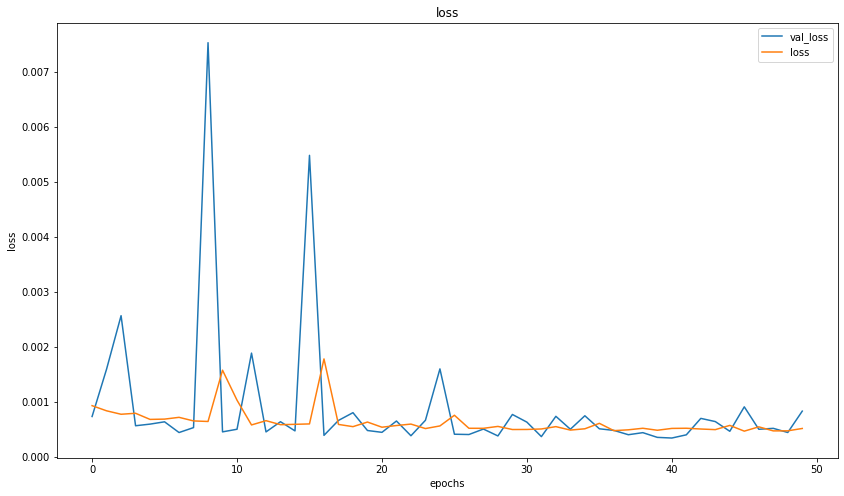

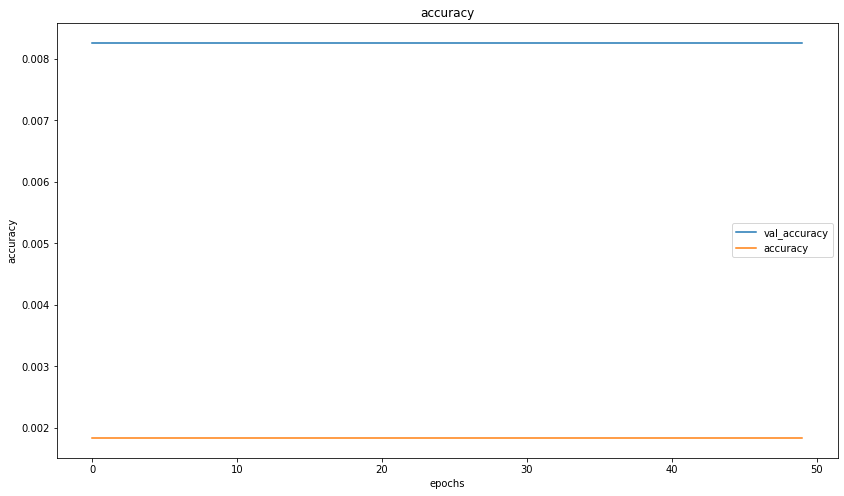

In [10]:
visualize_results(res)

range(1260, 1575)


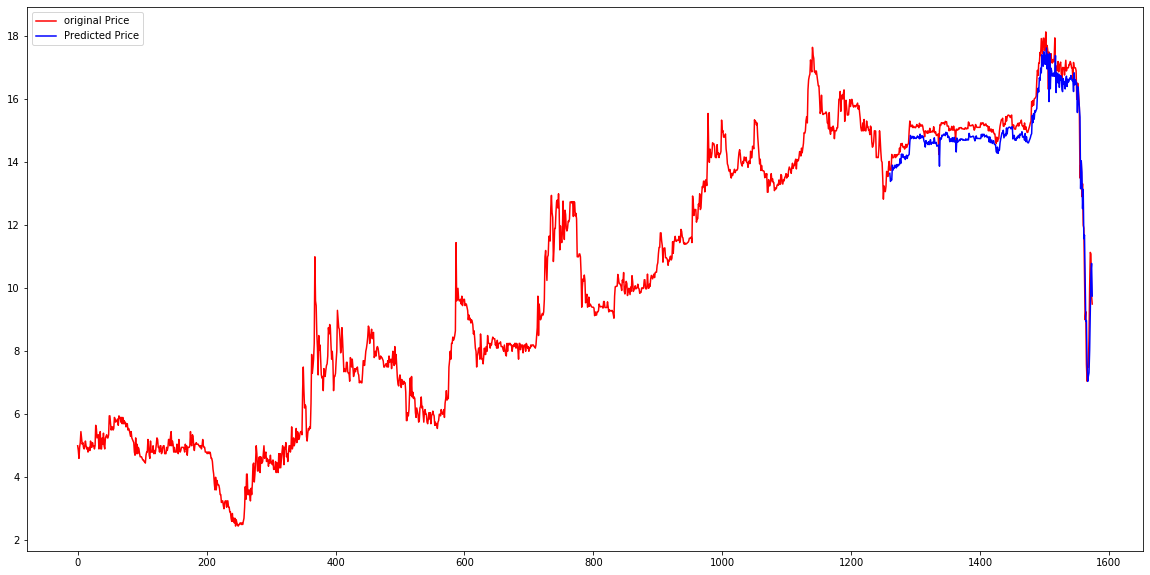

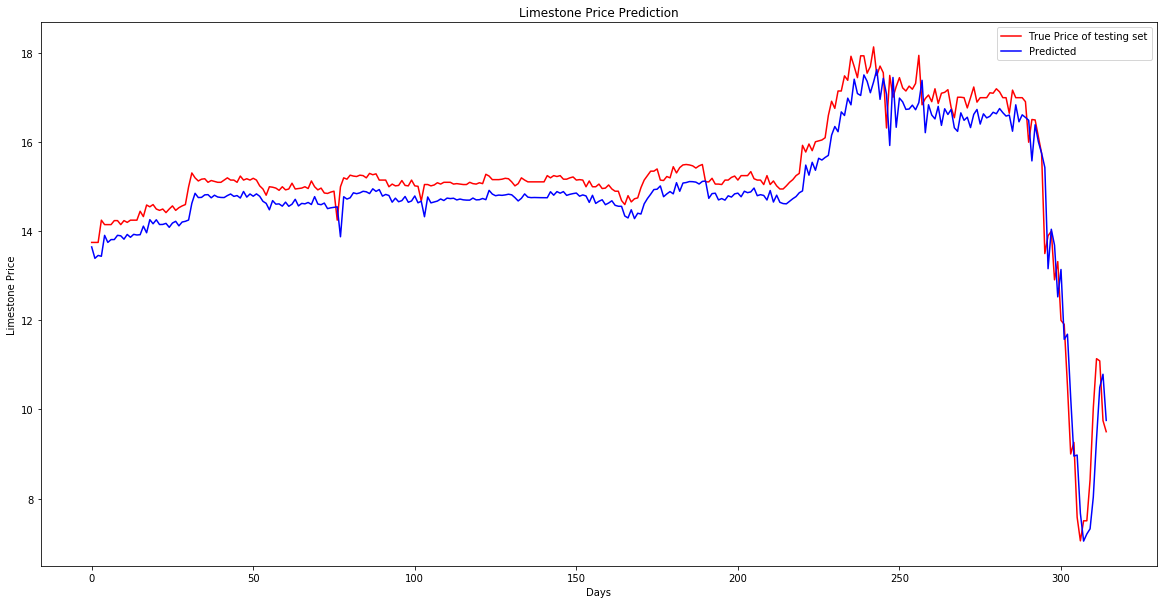

In [11]:

#visualizing our predictions
%matplotlib inline
predictions = model.predict(x_test)
predictions = scaler.inverse_transform(predictions)

fig, ax = plt.subplots(figsize=(20,10))
plt.plot(df, color='red', label='original Price')
ax.plot(range(len(y_train)+50, len(y_train)+50+len(predictions)),predictions,color='blue', label='Predicted Price')
plt.legend()
print(range(len(y_train)+50, len(y_train)+50+len(predictions)))

y_test_scaled = scaler.inverse_transform(y_test.reshape(-2,1))

fig, ax = plt.subplots(figsize=(20,10))
ax.plot(y_test_scaled, color='red', label = 'True Price of testing set')
plt.plot(predictions, color = 'blue', label='Predicted')
plt.legend()
plt.title('Limestone Price Prediction')
plt.xlabel('Days')
plt.ylabel('Limestone Price')
plt.show()